# Cargamos tablas y dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_excel("greenshop_pedidos.xlsx")
df

,pedido_id,cliente_id,fecha_pedido,categoria,importe,n_productos,devuelto,canal
0,PED00001,CLI0159,2023-07-09,Bebidas_Eco,52.99,4,False,web
1,PED00002,CLI0186,2024-02-23,Hogar,104.36,7,False,web
2,PED00003,CLI0189,2024-01-19,Jardinería,64.68,7,False,app
3,PED00004,CLI0024,2023-06-18,Bebidas_Eco,68.18,3,False,marketplace
4,PED00005,CLI0148,2023-10-27,Cuidado_Personal,136.50,7,False,marketplace
...,...,...,...,...,...,...,...,...
795,PED00796,CLI0120,2023-10-03,Cuidado_Personal,136.44,1,False,web
796,PED00797,CLI0149,2024-01-31,Alimentación,194.66,4,False,web
797,PED00798,CLI0122,2023-06-30,Jardinería,119.00,6,False,web
798,PED00799,CLI0032,2023-09-30,Cuidado_Personal,147.23,6,False,web


# Primer análisis de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   pedido_id     800 non-null    object        
 1   cliente_id    800 non-null    object        
 2   fecha_pedido  800 non-null    datetime64[ns]
 3   categoria     800 non-null    object        
 4   importe       800 non-null    float64       
 5   n_productos   800 non-null    int64         
 6   devuelto      800 non-null    bool          
 7   canal         800 non-null    object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 44.7+ KB


In [4]:
df.describe()

,fecha_pedido,importe,n_productos
count,800,800.000000,800.000000
mean,2023-11-28 12:54:00.000000256,106.271012,4.087500
min,2023-06-01 00:00:00,15.120000,1.000000
25%,2023-08-29 00:00:00,59.680000,2.000000
50%,2023-11-23 12:00:00,105.560000,4.000000
75%,2024-02-25 00:00:00,151.847500,6.000000
max,2024-05-30 00:00:00,199.920000,7.000000
std,NaN,53.060428,1.942823


In [5]:
print(f"Nulos")
print(df.isnull().sum())
print(f"Canales disponibles:")
print(df["canal"].value_counts())
print(f"Categorías de producto:")
print(df["categoria"].value_counts())

Nulos
pedido_id       0
cliente_id      0
fecha_pedido    0
categoria       0
importe         0
n_productos     0
devuelto        0
canal           0
dtype: int64
Canales disponibles:
canal
web            440
app            233
marketplace    127
Name: count, dtype: int64
Categorías de producto:
categoria
Alimentación        170
Bebidas_Eco         166
Cuidado_Personal    162
Jardinería          160
Hogar               142
Name: count, dtype: int64


# Limpieza y filtrado

In [6]:
# Filtrar solo por web y por app
df_filtrado = df[df["canal"].isin(["web", "app"])].copy()
print(f"Canales disponibles:")
print(df_filtrado["canal"].value_counts())

# Verificar que no existen ni nulos ni negativos ni cero
print(f"\n Importes negativos: {(df_filtrado["importe"]<=0).sum()}")

Canales disponibles:
canal
web    440
app    233
Name: count, dtype: int64

 Importes negativos: 0


In [7]:
# Separamos las dos muestras que vamos a comparar
web = df_filtrado[df_filtrado['canal'] == 'web']['importe']
app = df_filtrado[df_filtrado['canal'] == 'app']['importe']

#Tabla resumen por grupo
resumen = df_filtrado.groupby("canal")["importe"].agg(
    N="count",
    Media="mean",
    Mediana="median",
    Desv_Tipica="std",
    Minimo="min",
    Maximo="max"
).round(2)

print(resumen)

         N   Media  Mediana  Desv_Tipica  Minimo  Maximo
canal                                                   
app    233  106.22   115.23        54.72   15.37  199.19
web    440  106.02   104.45        53.32   16.27  199.92


# EDA

/tmp/ipykernel_3458/714819605.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtrado, x='canal', y='importe', ax=axes[2],


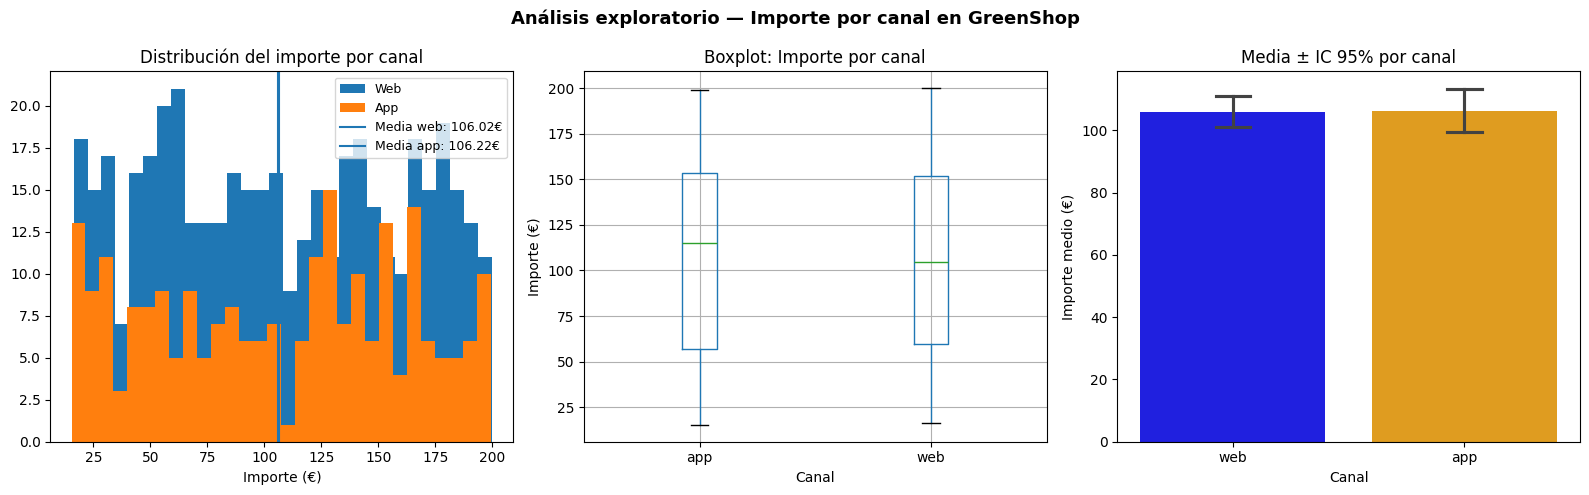

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Histograma solapado con líneas de media
axes[0].hist(web, bins=30,  label='Web')
axes[0].hist(app, bins=30, label='App')
axes[0].axvline(web.mean(), label=f'Media web: {web.mean():.2f}€')
axes[0].axvline(app.mean(), label=f'Media app: {app.mean():.2f}€')
axes[0].set_title('Distribución del importe por canal')
axes[0].set_xlabel('Importe (€)')
axes[0].legend(fontsize=9)

# Gráfico 2: Boxplot — mediana, IQR y outliers
df_filtrado.boxplot(column='importe', by='canal', ax=axes[1])
axes[1].set_title('Boxplot: Importe por canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Importe (€)')
plt.title('Boxplot: Importe por canal')

# Gráfico 3: Media con intervalo de confianza del 95%
sns.barplot(data=df_filtrado, x='canal', y='importe', ax=axes[2],
            palette=['blue','orange'], capsize=0.15)
axes[2].set_title('Media ± IC 95% por canal')
axes[2].set_xlabel('Canal')
axes[2].set_ylabel('Importe medio (€)')

plt.suptitle('Análisis exploratorio — Importe por canal en GreenShop',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


* Histograma: las distribuciones se solapan muchísimo. Las líneas de media están casi encima una de la otra.
* Boxplot: las medianas (línea roja) están a alturas muy similares. Los rangos intercuartílicos son prácticamente iguales.
* Barplot con IC 95%: los intervalos de confianza se solapan totalmente.

El EDA ya nos está lanzando una señal muy clara: probablemente no hay diferencia real. Pero necesitamos el test para cuantificarlo con rigor.

# Supuesto 1 — Normalidad (Test de Shapiro-Wilk)
El t-test asume que los datos provienen de una distribución normal (o que la muestra es suficientemente grande para que el Teorema Central del Límite lo garantice). Verificamos con Shapiro-Wilk:

In [10]:
# Test de Shapiro-Wilk
# H₀ de Shapiro: los datos SÍ siguen una distribución normal
# Si p > 0.05 → no rechazamos normalidad → podemos usar el t-test con confianza

from scipy import stats

stat_web, p_shapiro_web = stats.shapiro(web)
stat_app, p_shapiro_app = stats.shapiro(app)

print('--- TEST DE NORMALIDAD (Shapiro-Wilk) ---')
print(f'Web: estadístico = {stat_web:.4f}  |  p-valor = {p_shapiro_web:.6f}')
print(f'App: estadístico = {stat_app:.4f}  |  p-valor = {p_shapiro_app:.6f}')

alpha = 0.05
for grupo, p_val in [('Web', p_shapiro_web), ('App', p_shapiro_app)]:
    if p_val > alpha:
        print(f'  → {grupo}: p > 0.05  — No rechazamos normalidad')
    else:
        print(f'  → {grupo}: p ≤ 0.05  — Rechazamos normalidad formalmente')
        print( '     Pero: n > 30, el TCL nos cubre — el t-test sigue siendo válido.')


--- TEST DE NORMALIDAD (Shapiro-Wilk) ---
Web: estadístico = 0.9508  |  p-valor = 0.000000
App: estadístico = 0.9467  |  p-valor = 0.000000
  → Web: p ≤ 0.05  — Rechazamos normalidad formalmente
     Pero: n > 30, el TCL nos cubre — el t-test sigue siendo válido.
  → App: p ≤ 0.05  — Rechazamos normalidad formalmente
     Pero: n > 30, el TCL nos cubre — el t-test sigue siendo válido.


# Supuesto 2 — Homogeneidad de varianzas (Test de Levene)

In [11]:
# Test de Levene para igualdad de varianzas
# H₀ de Levene: las varianzas de ambos grupos son iguales
# Si p > 0.05 → podemos usar equal_var=True (t-test de Student clásico)
# Si p ≤ 0.05 → usamos equal_var=False (t-test de Welch, más robusto)

stat_lev, p_levene = stats.levene(web, app)

print('--- TEST DE IGUALDAD DE VARIANZAS (Levene) ---')
print(f'Estadístico Levene: {stat_lev:.4f}')
print(f'p-valor:            {p_levene:.4f}')

if p_levene > alpha:
    print('→ No rechazamos H₀ de Levene — varianzas iguales ✅')
    print(f'  (std web = {web.std():.2f}€ vs std app = {app.std():.2f}€)')
    equal_var = True
else:
    print('→ Rechazamos H₀ de Levene — varianzas distintas ⚠️')
    equal_var = False
    print('  Usaremos equal_var=False (variante de Welch, más conservadora)')


--- TEST DE IGUALDAD DE VARIANZAS (Levene) ---
Estadístico Levene: 0.3994
p-valor:            0.5276
→ No rechazamos H₀ de Levene — varianzas iguales ✅
  (std web = 53.32€ vs std app = 54.72€)


# T-test

In [12]:
# T-TEST DE DOS MUESTRAS INDEPENDIENTES
t_stat, p_valor = stats.ttest_ind(web, app,
                                   equal_var=True)

print('━' * 52)
print('          RESULTADO DEL T-TEST')
print('━' * 52)
print(f'  Media web:      {web.mean():.2f} €')
print(f'  Media app:      {app.mean():.2f} €')
print(f'  Diferencia:     {abs(web.mean()-app.mean()):.2f} €')
print(f'  Estadístico t:  {t_stat:.4f}')
print(f'  p-valor:        {p_valor:.4f}')
print(f'  Nivel α:        {alpha}')
print('━' * 52)

if p_valor <= alpha:
    print('  CONCLUSIÓN: Rechazamos H₀')
    print('  → Hay evidencia estadística de diferencia entre canales.')
else:
    print('  CONCLUSIÓN: NO rechazamos H₀')
    print('  → No hay evidencia estadística de diferencia entre canales.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
          RESULTADO DEL T-TEST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Media web:      106.02 €
  Media app:      106.22 €
  Diferencia:     0.20 €
  Estadístico t:  -0.0450
  p-valor:        0.9641
  Nivel α:        0.05
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CONCLUSIÓN: NO rechazamos H₀
  → No hay evidencia estadística de diferencia entre canales.


# Anova

## EDA previo

In [ ]:
#Estadísticos por categoriía
resumen_cat = df.groupby("categoria")["importe"].agg(
    N="count",
    Media="mean",
    Mediana="median",
    Desv="std"
).round(2)
print(resumen_cat)

                    N   Media  Mediana   Desv
categoria                                    
Alimentación      170  109.91   108.40  54.45
Bebidas_Eco       166  101.07    99.42  50.68
Cuidado_Personal  162  109.14   105.99  52.06
Hogar             142  104.95   104.65  54.18
Jardinería        160  106.08   115.14  54.14


## Visualización previa

/tmp/ipykernel_3458/2243043861.py:12: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(data=df, x='categoria', y='importe', ax=axes[1],
/tmp/ipykernel_3458/2243043861.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(data=df, x='categoria', y='importe', ax=axes[1],


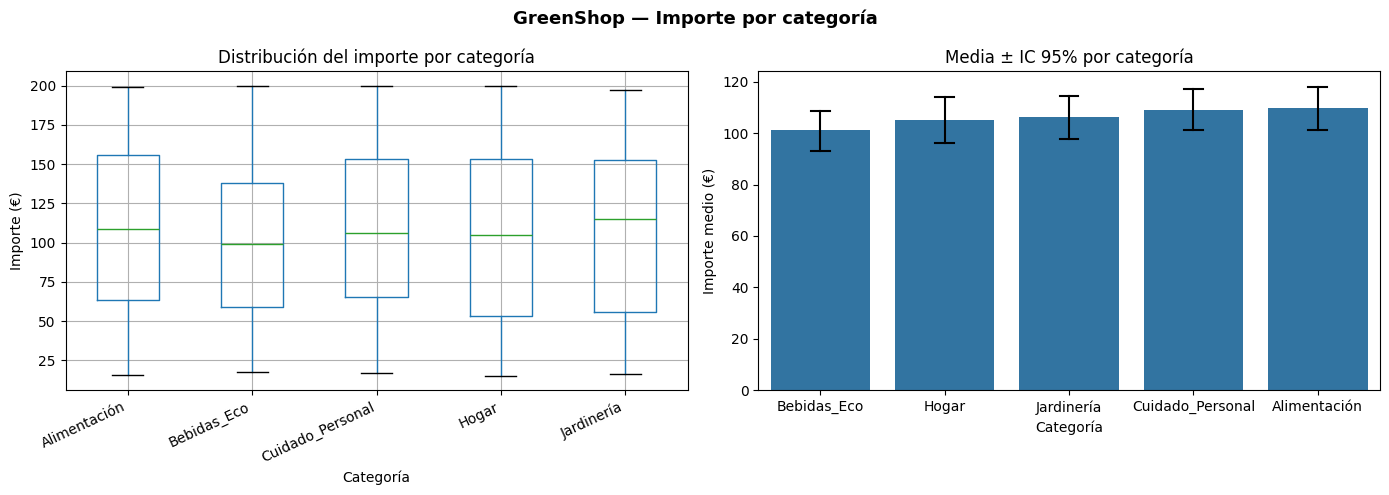

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por categoría
df.boxplot(column='importe', by='categoria', ax=axes[0])
axes[0].set_title('Distribución del importe por categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Importe (€)')
plt.sca(axes[0])
plt.xticks(rotation=25, ha='right')

# Barplot con IC 95%
sns.barplot(data=df, x='categoria', y='importe', ax=axes[1],
            capsize=0.15, errcolor='black', errwidth=1.5)
axes[1].set_title('Media ± IC 95% por categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Importe medio (€)')
plt.xticks(rotation=25, ha='right')

plt.suptitle('GreenShop — Importe por categoría', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Normalidad

In [14]:
# Con n > 30 en todos los grupos, el TCL nos cubre.
# Lo verificamos igualmente por rigor.
categorias = df['categoria'].unique()
print('--- SHAPIRO-WILK POR CATEGORÍA ---')
for cat in categorias:
    grupo = df[df['categoria'] == cat]['importe']
    stat, p = stats.shapiro(grupo)
    print(f'{cat:25s}  n={len(grupo)}  p={p:.4f}')


--- SHAPIRO-WILK POR CATEGORÍA ---
Bebidas_Eco                n=166  p=0.0001
Hogar                      n=142  p=0.0000
Jardinería                 n=160  p=0.0000
Cuidado_Personal           n=162  p=0.0000
Alimentación               n=170  p=0.0000


## F-test: Anova

In [16]:
grupos = []
# Separamos los grupos
for cat in categorias:
  grupos.append(df[df['categoria'] == cat]['importe'].values)

# ANOVA de una vía
f_stat, p_valor = stats.f_oneway(*grupos)

print(f'  Estadístico F:  {f_stat:.4f}')
print(f'  p-valor:        {p_valor:.6f}')

if p_valor <= 0.05:
    print('  CONCLUSIÓN: Rechazamos H₀')
    print('  → Al menos una categoría tiene importe medio distinto.')
else:
    print('  CONCLUSIÓN: No rechazamos H₀')
    print('  → No hay evidencia de diferencia entre categorías.')
# Separamos los grupos
    print('  → No hay evidencia de diferencia entre categorías.')


  Estadístico F:  0.7383
  p-valor:        0.565972
  CONCLUSIÓN: No rechazamos H₀
  → No hay evidencia de diferencia entre categorías.
  → No hay evidencia de diferencia entre categorías.


## Test de Tukey

In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['importe'],
    groups=df['categoria'],
    alpha=0.05
)
print(tukey.summary())


           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    Alimentación      Bebidas_Eco   -8.839  0.546 -24.6789  7.0009  False
    Alimentación Cuidado_Personal   -0.772 0.9999 -16.7106 15.1665  False
    Alimentación            Hogar  -4.9611 0.9239 -21.4643 11.5422  False
    Alimentación       Jardinería  -3.8328 0.9656 -19.8222 12.1567  False
     Bebidas_Eco Cuidado_Personal    8.067 0.6435   -7.965 24.0989  False
     Bebidas_Eco            Hogar    3.878 0.9686 -12.7156 20.4715  False
     Bebidas_Eco       Jardinería   5.0062 0.9144 -11.0764 21.0888  False
Cuidado_Personal            Hogar   -4.189 0.9594 -20.8767 12.4987  False
Cuidado_Personal       Jardinería  -3.0607 0.9856 -19.2405  13.119  False
           Hogar       Jardinería   1.1283 0.9997 -15.6081 17.8646  False
--------------------------------------

# Regresión lineal

## Regresión lineal simple

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Preparamos X e y
X = df[['n_productos']]   # Siempre 2D para sklearn
y = df['importe']

# Train/test split — 80% entrenamiento, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f'Intercepto (β₀):  {modelo.intercept_:.2f} €')
print(f'Pendiente  (β₁):  {modelo.coef_[0]:.2f} € por producto adicional')

Intercepto (β₀):  104.63 €
Pendiente  (β₁):  0.07 € por producto adicional


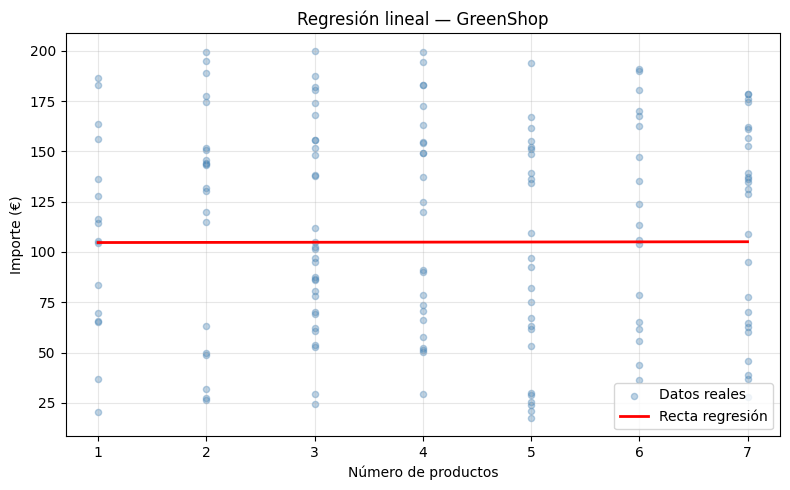

In [22]:
# Predecir y evaluar
y_pred = modelo.predict(X_test)

r2  = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Visualización: recta de regresión sobre los datos
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test, y_test, alpha=0.35, color='steelblue',
           s=20, label='Datos reales')
ax.plot(X_test.sort_values('n_productos'),
        modelo.predict(X_test.sort_values('n_productos')),
        color='red', linewidth=2, label='Recta regresión')
ax.set_xlabel('Número de productos')
ax.set_ylabel('Importe (€)')
ax.set_title('Regresión lineal — GreenShop')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Regresión con muy muy malos resultados

## Regresión lineal múltiple

In [23]:

# ── Preparamos X con get_dummies (OHE en una línea) ──────────
X = pd.get_dummies(df[['n_productos', 'canal', 'categoria']], drop_first=True)
y = df['importe']

# ── Train/test split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Entrenamos ───────────────────────────────────────────────
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# ── Evaluamos ────────────────────────────────────────────────
y_pred = modelo.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f'R²:    {r2:.4f}  ({r2*100:.1f}% varianza explicada)')
print(f'RMSE:  {rmse:.2f} €')
coef_list = []

for i, col in enumerate(X.columns):
    coef_list.append({
        'variable': col,
        'coeficiente': modelo.coef_[i]
    })

coef_df = pd.DataFrame(coef_list)
print(coef_df.to_string(index=False))


R²:    -0.0292  (-2.9% varianza explicada)
RMSE:  52.76 €
                  variable  coeficiente
               n_productos     0.013953
         canal_marketplace     4.980884
                 canal_web     0.681094
     categoria_Bebidas_Eco    -8.451092
categoria_Cuidado_Personal    -1.605468
           categoria_Hogar   -10.139625
      categoria_Jardinería    -3.935806
